# Convolution and Correlation Utilities

## Theory

### Convolution

The **convolution** of a signal $x[n]$ with a kernel/filter $h[n]$ is defined as:

$$
y[n] = (x * h)[n] = \sum_{k=-\infty}^{\infty} x[k] \; h[n-k]
$$

In DSP, convolution models the effect of passing a signal through a linear time-invariant system (filtering, echo, etc).

**In sonar:** Convolution can simulate echoes (multipath), system response, or matched filter output.

---

### Correlation

The **cross-correlation** of signals $x[n]$ and $y[n]$ measures similarity as you slide one past the other:

$$
r_{xy}[m] = \sum_{n=-\infty}^{\infty} x[n] \; y[n+m]
$$

- Maximum value (peak) shows the lag (delay) where signals best align.
- **In sonar:** Used for detection (matched filtering), delay/time-of-flight estimation, event synchronization.

---


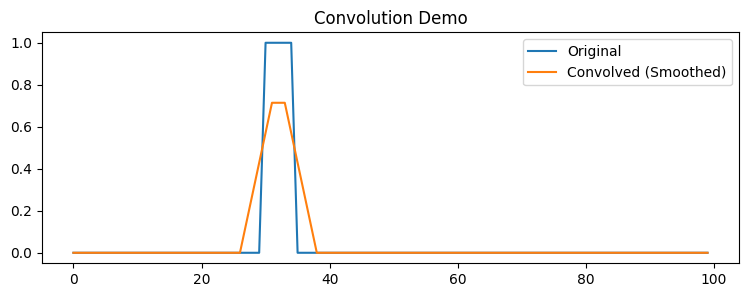

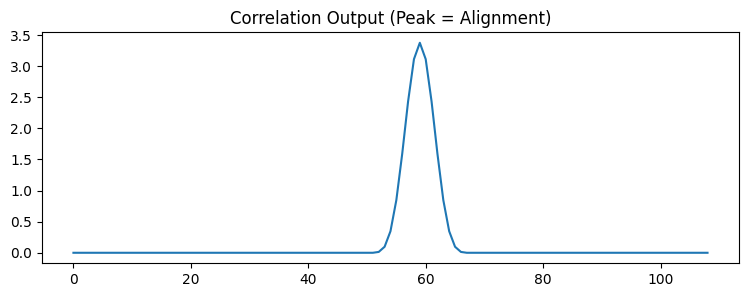

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, correlate

def convolve_signals(signal, kernel, mode='same'):
    """Convolve signal with kernel (filter/impulse response)."""
    return convolve(signal, kernel, mode=mode)

def correlate_signals(sig1, sig2, mode='full'):
    """Cross-correlation between sig1 and sig2."""
    return correlate(sig1, sig2, mode=mode)

# --- DEMOS ---
# 1. Convolution (smoothing)
x = np.zeros(100)
x[30:35] = 1  # Simple pulse
kernel = np.ones(7) / 7  # Smoothing kernel
conv_result = convolve_signals(x, kernel)

plt.figure(figsize=(9,3))
plt.plot(x, label='Original')
plt.plot(conv_result, label='Convolved (Smoothed)')
plt.legend(); plt.title('Convolution Demo'); plt.show()

# 2. Correlation (detecting delay)
sig = np.zeros(100)
sig[50:60] = np.hanning(10)
template = np.hanning(10)
corr = correlate_signals(sig, template)

plt.figure(figsize=(9,3))
plt.plot(corr)
plt.title('Correlation Output (Peak = Alignment)')
plt.show()


## Notes
- Use **convolution** for filtering, simulating echoes/system response.
- Use **correlation** for lag/delay estimation, detection, synchronization.

---
